In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import torch
import pandas as pd
import torch.nn as nn

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

In [3]:
num_geom = 20
electrode_pairs = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 0]
]

current_list_0 = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_exp_from_paper/en_dis=0.01/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.01.npz')
        current_list_0.append(data['current'])

currents_0 = np.stack(current_list_0) * 1e12 * 1e9
average_current_0 = currents_0.mean(axis=0)
std_current_0 = currents_0.std(axis=0)

p_50_0 = np.percentile(currents_0, 50, axis=0)

current_list_1 = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_exp_from_paper/en_dis=0.1/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.1.npz')
        current_list_1.append(data['current'])

currents_1 = np.stack(current_list_1) * 1e12 * 1e9
average_current_1 = currents_1.mean(axis=0)
std_current_1 = currents_1.std(axis=0)

p_50_1= np.percentile(currents_1, 50, axis=0)

current_list_2 = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_exp_from_paper/en_dis=0.05/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.05.npz')
        current_list_2.append(data['current'])

currents_2 = np.stack(current_list_2) * 1e12 * 1e9
average_current_2 = currents_2.mean(axis=0)
std_current_2 = currents_2.std(axis=0)

p_50_2 = np.percentile(currents_2, 50, axis=0)

current_list_3 = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_exp_from_paper/en_dis=0.0/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.0.npz')
        current_list_3.append(data['current'])

currents_3 = np.stack(current_list_3) * 1e12 * 1e9
average_current_3 = currents_3.mean(axis=0)
std_current_3 = currents_3.std(axis=0)

p_50_3 = np.percentile(currents_3, 50, axis=0)

current_list_wit_T = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_from_paper_with_T/en_dis=0.0/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.0.npz')
        current_list_wit_T.append(data['current'])

currents_with_T = np.stack(current_list_wit_T) * 1e12 * 1e9
average_current_with_T = currents_with_T.mean(axis=0)
std_current_with_T = currents_with_T.std(axis=0)

p_50_T = np.percentile(currents_with_T, 50, axis=0)

"fig, axs = plt.subplot_mosaic(mosaic=mosaic_layout, figsize=(12,6), layout='constrained')\n\nfor ax in axs.values():\n    ax.spines[:].set_linewidth(1.5)\n\naxs['B'].set_aspect('equal')\naxs['C'].set_aspect('equal')\n\naxs['A'].grid(ls='--', c='w')\naxs['A'].tick_params(direction='in')\naxs['A'].set_facecolor('lavender')\n\naxs['A'].set_xlabel(r'$V_{\\mathrm{in}}$ $[ V ]$')\naxs['A'].set_ylabel(r'$I_{\\mathrm{out}}$ $[ \nu_0 e_0 ]$')\n\naxs['A'].fill_between(v, average_current_0-p_50_0, average_current_0+p_50_0, alpha=0.4, zorder=5)\naxs['A'].fill_between(v, average_current_1-p_50_1, average_current_1+p_50_2, alpha=0.4, zorder=5)\naxs['A'].fill_between(v, average_current_2-p_50_2, average_current_2+p_50_2, alpha=0.4, zorder=5)\n\naxs['A'].plot(v, average_current_0)\naxs['A'].plot(v, average_current_1)\naxs['A'].plot(v, average_current_2)"

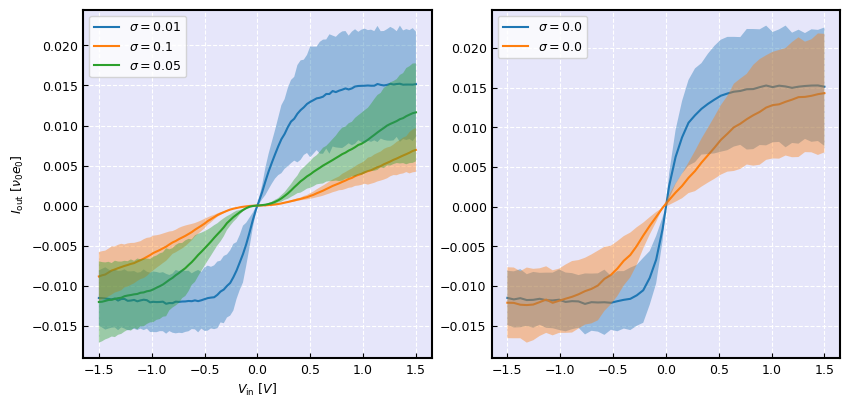

In [4]:
v = np.linspace(-1.5, 1.5, average_current_0.shape[0])
scale = 1.5
fig, ax = plt.subplots(figsize=(width_in_pt * scale, height_in_pt * scale), ncols=2, constrained_layout=True)

for a in ax:
    a.set_box_aspect(1)

ax[0].set_xlabel(r'$V_{\mathrm{in}}$ $[ V ]$')
ax[0].set_ylabel(r'$I_{\mathrm{out}}$ $[ \nu_0 e_0 ]$')

ax[0].fill_between(v, average_current_0-p_50_0, average_current_0+p_50_0, alpha=0.4, zorder=5)
ax[0].plot(v, average_current_0, label=rf'$\sigma = 0.01$')

ax[0].fill_between(v, average_current_1-p_50_1, average_current_1+p_50_1, alpha=0.4, zorder=5)
ax[0].plot(v, average_current_1, label=rf'$\sigma = 0.1$')

ax[0].fill_between(v, average_current_2-p_50_2, average_current_2+p_50_2, alpha=0.4, zorder=5)
ax[0].plot(v, average_current_2, label=rf'$\sigma = 0.05$')

ax[0].spines[:].set_linewidth(1.5)
ax[0].grid(ls='--', c='w')
ax[0].tick_params(direction='in')
ax[0].set_facecolor('lavender')

ax[1].fill_between(np.linspace(-1.5, 1.5, 50), average_current_3-p_50_3, average_current_3+p_50_3, alpha=0.4, zorder=5)
ax[1].plot(np.linspace(-1.5, 1.5, 50), average_current_3, label=rf'$\sigma = 0.0$')

ax[1].fill_between(np.linspace(-1.5, 1.5, 50), average_current_with_T-p_50_T, average_current_with_T+p_50_T, alpha=0.4, zorder=5)
ax[1].plot(np.linspace(-1.5, 1.5, 50), average_current_with_T, label=rf'$\sigma = 0.0$')

ax[1].spines[:].set_linewidth(1.5)
ax[1].grid(ls='--', c='w')
ax[1].tick_params(direction='in')
ax[1].set_facecolor('lavender')

ax[0].legend()
ax[1].legend()

plt.savefig(f'/home/hd/hd_hd/hd_gy283/kmc_project/plots/iv_curves.png')

mosaic_layout = [
    ['A', 'B'],
    ['A', 'C']    
]

"""fig, axs = plt.subplot_mosaic(mosaic=mosaic_layout, figsize=(12,6), layout='constrained')

for ax in axs.values():
    ax.spines[:].set_linewidth(1.5)

axs['B'].set_aspect('equal')
axs['C'].set_aspect('equal')

axs['A'].grid(ls='--', c='w')
axs['A'].tick_params(direction='in')
axs['A'].set_facecolor('lavender')

axs['A'].set_xlabel(r'$V_{\mathrm{in}}$ $[ V ]$')
axs['A'].set_ylabel(r'$I_{\mathrm{out}}$ $[ \nu_0 e_0 ]$')

axs['A'].fill_between(v, average_current_0-p_50_0, average_current_0+p_50_0, alpha=0.4, zorder=5)
axs['A'].fill_between(v, average_current_1-p_50_1, average_current_1+p_50_2, alpha=0.4, zorder=5)
axs['A'].fill_between(v, average_current_2-p_50_2, average_current_2+p_50_2, alpha=0.4, zorder=5)

axs['A'].plot(v, average_current_0)
axs['A'].plot(v, average_current_1)
axs['A'].plot(v, average_current_2)"""